Greyson Roy \
8/25/2026 \
Lab 1 - Projectile Motion Solver

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Part A - One-Dimensional Free Fall

1. Below is the simulate_freefall function.

In [2]:
def simulate_freefall(h,dt,g):
    y = h
    vy = 0
    t = 0
    y_store = [h]
    vy_store = [vy]
    t_store = [0]
    while y >= 0:
        vy += -dt*g
        y += dt*vy
        t += dt
        y_store.append(y)
        vy_store.append(vy)
        t_store.append(t)
    return y_store, vy_store, t_store

2. Below is the run for the given parameters.
3. Below is the plot of y vs t.

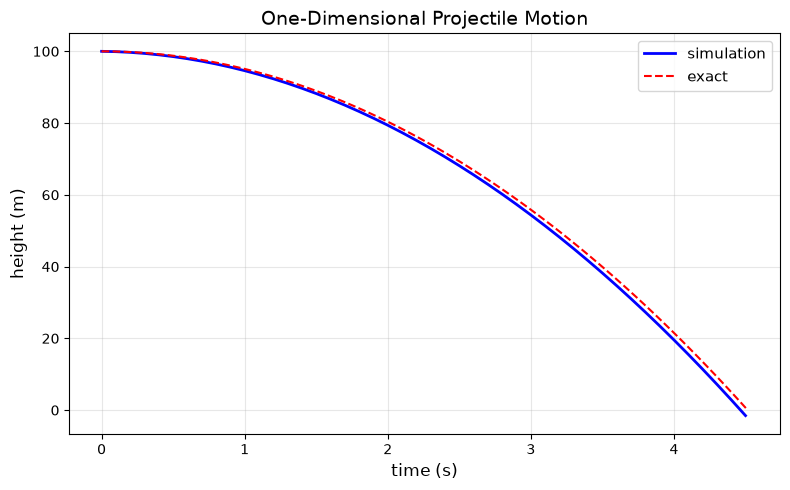

The numerical landing time is: 4.5, The exact final landing time is:  4.515, The percentage error is:  0.337


In [3]:
h = 100
dt = 0.1
g = 9.81
y_data, vy_data, t_data = simulate_freefall(100,0.1,9.81)
t_final_exact = np.sqrt(2*h/g)
t_final_data = t_data[-1]
t_exact = np.linspace(0,t_final_exact,100)
y_exact = h - 0.5*g*t_exact**2

plt.figure(figsize=(8,5))
plt.plot(t_data, y_data, 'b-', label='simulation', linewidth=2)
plt.plot(t_exact, y_exact, 'r--', label='exact', linewidth=1.5)
plt.xlabel('time (s)', fontsize=12)
plt.ylabel('height (m)', fontsize=12)
plt.title('One-Dimensional Projectile Motion', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'The numerical landing time is: {t_final_data}, The exact final landing time is: {t_final_exact: .3f}, The percentage error is: {100*abs(t_final_exact-t_final_data)/t_final_exact: .3f}')


In [4]:
t1_data = simulate_freefall(100,1,9.81)[2]
t1_final = t1_data[-1]
t1_error = 100*abs(t1_final-t_final_exact)/t_final_exact
t001_data = simulate_freefall(100,0.01,9.81)[2]
t001_final = t001_data[-1]
t001_error = 100*abs(t001_final-t_final_exact)/t_final_exact
print(t1_final, t1_error, t001_final, t001_error)

5 10.736172951750511 4.519999999999948 0.1055003483813113


4. The numerical landing time is: 4.5 (dt=0.1), The exact final landing time is:  4.515s, The error is:  0.337%
For dt = 1, the numerical landing time is 5s with an error of 10.736%. 
For dt = 0.01, the numerical landing time is 4.52 with an error of 0.106%.
From this, we can see that decreasing the time step, dt, we use for euler's method, we can decrease the error.

Part B - Two-Dimensional Projectile

1. The simulate_projectile_2d function is below.

In [5]:
def simulate_projectile_2d(v0, theta_deg, dt, g):
    theta_rad = np.deg2rad(theta_deg)
    vx = v0*np.cos(theta_rad)
    vy = v0*np.sin(theta_rad)
    x = 0
    y = 0
    t = 0
    state = [[x, y, vx, vy, t]]
    while y>=0:
        vx += 0
        vy += -g*dt
        y += vy*dt
        x += vx*dt
        t += dt
        state.append([x, y, vx, vy, t])
    return state

2. Below is the run for the given parameters.
3. Below is the plot of y vs x.

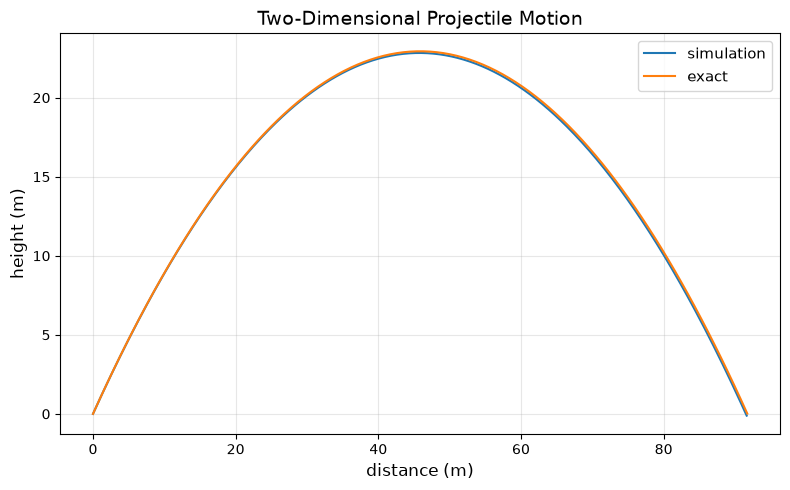

In [6]:
distance = [State[0] for State in simulate_projectile_2d(30, 45, 0.01, 9.81)]
height = [State[1] for State in simulate_projectile_2d(30, 45, 0.01, 9.81)]

x_exact = [30*np.cos(np.deg2rad(45))*t for t in np.linspace(0, 4.324, 100, True)]
y_exact = [30*np.cos(np.deg2rad(45))*t - 9.81*t**2/2 for t in np.linspace(0, 4.324, 100, True)]

plt.figure(figsize=(8,5))
plt.plot(distance, height, label='simulation')
plt.plot(x_exact, y_exact, label='exact')
plt.xlabel('distance (m)', fontsize=12)
plt.ylabel('height (m)', fontsize=12)
plt.title('Two-Dimensional Projectile Motion', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



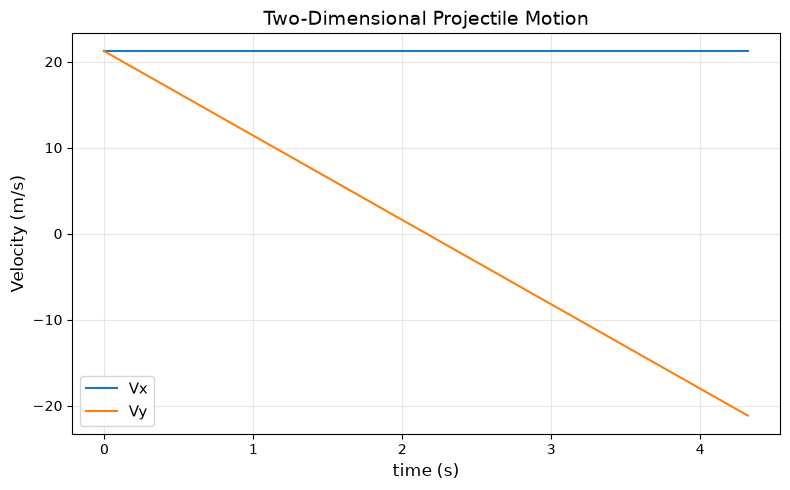

In [7]:
t = [State[4] for State in simulate_projectile_2d(30, 45, 0.01, 9.81)]
Vx = [State[2] for State in simulate_projectile_2d(30, 45, 0.01, 9.81)]
Vy = [State[3] for State in simulate_projectile_2d(30, 45, 0.01, 9.81)]

plt.figure(figsize=(8,5))
plt.plot(t, Vx, label='Vx')
plt.plot(t, Vy, label='Vy')
plt.xlabel('time (s)', fontsize=12)
plt.ylabel('Velocity (m/s)', fontsize=12)
plt.title('Two-Dimensional Projectile Motion', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


4. From the above plot we can see that for the no drag case of two dimensional projectile motion, the x velocity stays constant as there is net x force is zero. The velocity in the y direction, on the other hand, decreases at a linear rate, due to the constant force of gravity applied in the downward direction.

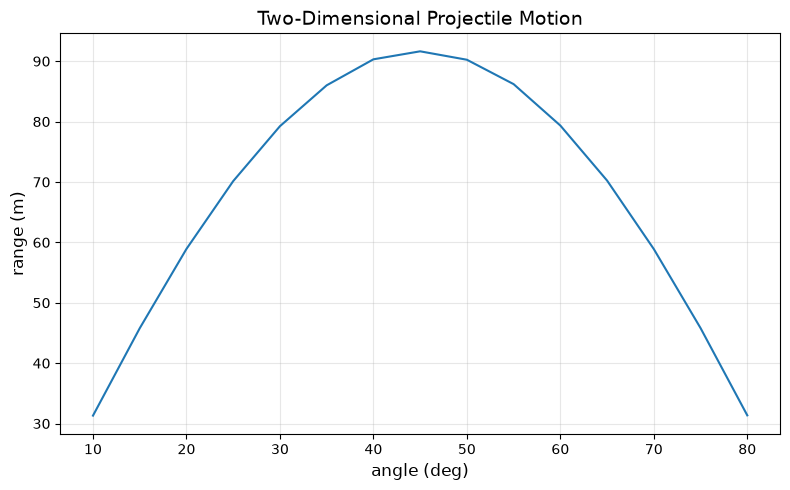

The error for max height is 0.4803686970864736% and the error for range is 0.10787133008887208%


In [8]:
plt.figure(figsize=(8,5))

traj = {}
max_range = []
angle = []

for deg in range(10, 85, 5):
    key = f'{deg} deg'
    traj[key] = simulate_projectile_2d(30,deg,0.01,9.81)
    distance = [state[0] for state in traj[key]]
    max_range.append(distance[-1])
    angle.append(deg)

plt.plot(angle, max_range)
plt.xlabel('angle (deg)', fontsize=12)
plt.ylabel('range (m)', fontsize=12)
plt.title('Two-Dimensional Projectile Motion', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

range_45 = float([state[0] for state in simulate_projectile_2d(30, 45, 0.01, 9.81)][-1])
max_height_45 = max([state[1] for state in simulate_projectile_2d(30, 45, 0.01, 9.81)])
error_range_45 = 100*abs(91.74-range_45)/91.74
error_height_45 = 100*abs(22.94-max_height_45)/22.94
print(f'The error for max height is {error_height_45}% and the error for range is {error_range_45}%')

5. The height and range errors are printed above.

6. According to the above plot, range is maximized at 45 deg for the no drag case, which matches the theory.

Part C - Projectile with Air Resistance

1. The simulate_projectile_drag function is below.

In [9]:
def simulate_projectile_drag(v0, theta_deg, dt, g, b_over_m):
    theta_rad = np.deg2rad(theta_deg)
    vx = v0*np.cos(theta_rad)
    vy = v0*np.sin(theta_rad)
    x = 0
    y = 0
    t = 0
    state = [[x, y, vx, vy, t]]
    while y>=0:
        speed = np.sqrt(vx**2+vy**2)
        vx += -b_over_m*speed*vx*dt
        vy += (-g-b_over_m*speed*vy)*dt
        y += vy*dt
        x += vx*dt
        t += dt
        state.append([x, y, vx, vy, t])
    return state

2. The simulation with the given parameters is below.
3. The plot of drag and no drag trajectories is below.
4. The respective max heights and ranges, as well as the range error are printed below.

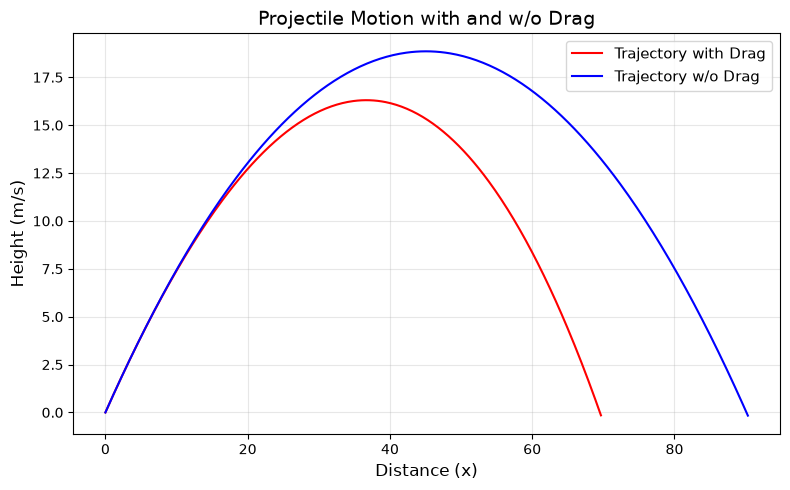

For the no drag case, the max height is 18.856725449568536 m and the range is 90.31663984372715 m
For the with drag case, the max height is 16.304950882023938 m and the range is 69.66065528805088 m
The drag reduces the range by 22.8706300316496


In [10]:
Drag_State = simulate_projectile_drag(30, 40, 0.01, 9.81, 0.0046)
No_Drag_State = simulate_projectile_2d(30, 40, 0.01, 9.81)

y_drag = [State[1] for State in Drag_State]
x_drag = [State[0] for State in Drag_State]
y_no_drag = [State[1] for State in No_Drag_State]
x_no_drag = [State[0] for State in No_Drag_State]

y_drag_max = max(y_drag)
x_drag_max = x_drag[-1]
y_no_drag_max = max(y_no_drag)
x_no_drag_max = x_no_drag[-1]

plt.figure(figsize=(8,5))
plt.plot(x_drag, y_drag, 'r-', label='Trajectory with Drag')
plt.plot(x_no_drag, y_no_drag, 'b-', label='Trajectory w/o Drag')
plt.xlabel('Distance (x)', fontsize=12)
plt.ylabel('Height (m/s)', fontsize=12)
plt.title('Projectile Motion with and w/o Drag', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'For the no drag case, the max height is {y_no_drag_max} m and the range is {x_no_drag_max} m')
print(f'For the with drag case, the max height is {y_drag_max} m and the range is {x_drag_max} m')
print(f'The drag reduces the range by {100*abs(x_no_drag_max-x_drag_max)/x_no_drag_max}')

5. The plot of speed vs time for the drag and no drag cases is below.

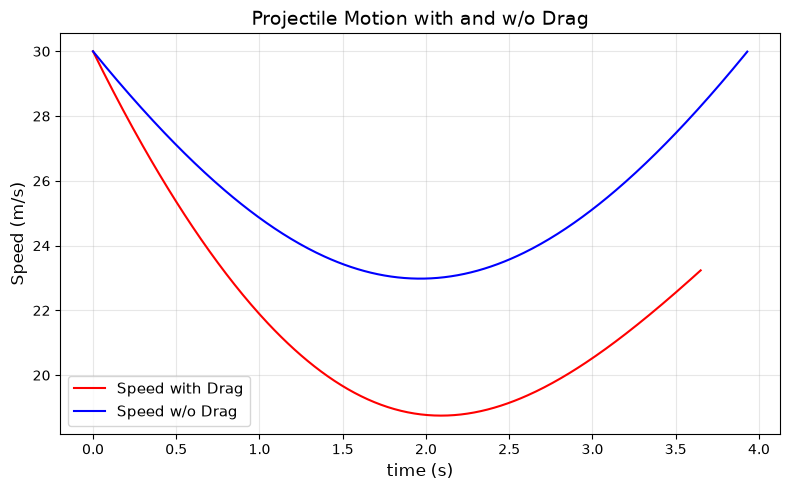

In [11]:
Drag_State = simulate_projectile_drag(30, 40, 0.01, 9.81, 0.0046)
No_Drag_State = simulate_projectile_2d(30, 40, 0.01, 9.81)

v_drag = [np.sqrt(State[2]**2+State[3]**2) for State in Drag_State]
t_drag = [State[4] for State in Drag_State]
v_no_drag = [np.sqrt(State[2]**2+State[3]**2) for State in No_Drag_State]
t_no_drag = [State[4] for State in No_Drag_State]

plt.figure(figsize=(8,5))
plt.plot(t_drag, v_drag, 'r-', label='Speed with Drag')
plt.plot(t_no_drag, v_no_drag, 'b-', label='Speed w/o Drag')
plt.xlabel('time (s)', fontsize=12)
plt.ylabel('Speed (m/s)', fontsize=12)
plt.title('Projectile Motion with and w/o Drag', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


6. The angle sweep is below. The range for the with drag case seems to be maximized somewhere between 40 and 45 deg based on the angle sweep but the sweep is too coarse to give a better estimate. In the bonus section, I found that the range is maximized for an angle of 41.732 deg.

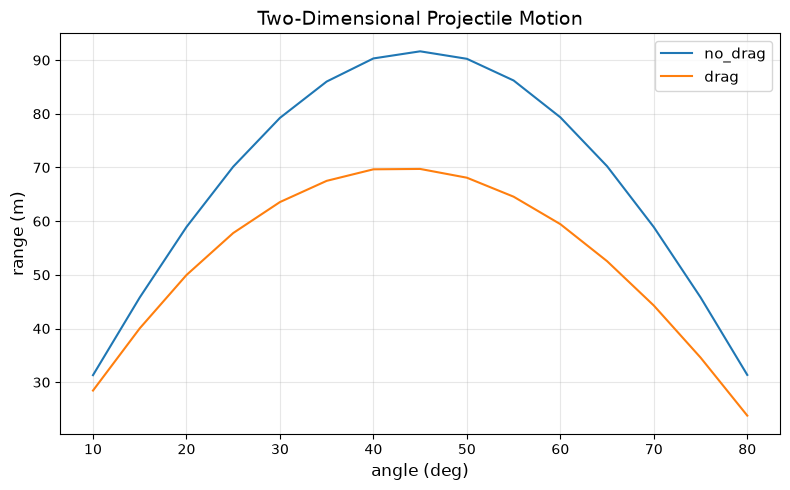

In [12]:
plt.figure(figsize=(8,5))

traj = {}
traj_drag = {}
max_range = []
max_range_drag = []
angle = []

for deg in range(10, 85, 5):
    key = f'{deg} deg'
    traj[key] = simulate_projectile_2d(30,deg,0.01,9.81)
    traj_drag[key] = simulate_projectile_drag(30,deg,0.01,9.81, 0.0046)
    distance = [state[0] for state in traj[key]]
    distance_drag = [state[0] for state in traj_drag[key]]
    max_range.append(distance[-1])
    max_range_drag.append(distance_drag[-1])
    angle.append(deg)

plt.plot(angle, max_range, label='no_drag')
plt.plot(angle, max_range_drag, label='drag')
plt.xlabel('angle (deg)', fontsize=12)
plt.ylabel('range (m)', fontsize=12)
plt.title('Two-Dimensional Projectile Motion', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Bonus - Homerun Challenge

In [13]:
def simulate_no_drag_homerun(v0, theta_deg, dt, g):
    theta_rad = np.deg2rad(theta_deg)
    vx = v0*np.cos(theta_rad)
    vy = v0*np.sin(theta_rad)
    x = 0
    y = 0
    t = 0
    while x<=120 and y>=0:
        vx += 0
        vy += -g*dt
        y += vy*dt
        x += vx*dt
        t += dt
    if y>=3:
        return True
    return False

def simulate_drag_homerun(v0, theta_deg, dt, g, b_over_m):
    theta_rad = np.deg2rad(theta_deg)
    vx = v0*np.cos(theta_rad)
    vy = v0*np.sin(theta_rad)
    x = 0
    y = 0
    t = 0
    while x<= 120 and y>=0:
        speed = np.sqrt(vx**2+vy**2)
        vx += -b_over_m*speed*vx*dt
        vy += (-g-b_over_m*speed*vy)*dt
        y += vy*dt
        x += vx*dt
        t += dt
    if y>=3:
        return True
    return False 

In [14]:
hr_deg_nd = []

for deg in range(0,90,1):
    if simulate_no_drag_homerun(45, deg, 0.01, 9.81):
        hr_deg_nd.append(deg)
print(f'With no drag, the ball hit 45 m/s is a homerun from angle {hr_deg_nd[0]} deg to {hr_deg_nd[-1]} deg')

hr_deg_d = []

for deg in range(0,90,1):
    if simulate_drag_homerun(45, deg, 0.01, 9.81, 0.0046):
        hr_deg_d.append(deg)
print(f'With drag, the ball hit 45 m/s is a homerun from angle {hr_deg_d[0]} deg to {hr_deg_d[-1]} deg')

With no drag, the ball hit 45 m/s is a homerun from angle 20 deg to 72 deg
With drag, the ball hit 45 m/s is a homerun from angle 37 deg to 47 deg


1. At an initial velocity of 45 m/s, from angles 20 deg to 72 deg the hit is a homerun.
2. At an initial velocity of 45 m/s, from angles 37 deg to 47 deg the hit is a homerun.

Finding the Optimal Angle and Speed for w/ Drag

In [15]:
optimal_deg = [37,47]
speed = 45
while True:
    current_deg = []
    speed += -.001
    for deg in np.linspace(optimal_deg[0], optimal_deg[-1], 10):
        if simulate_drag_homerun(speed, deg, 0.01, 9.81, 0.0046):
            current_deg.append(float(deg))
    if current_deg == []:
        break
    optimal_deg = current_deg

print(f'The optimal speed and angle/s is {speed + 0.001} m/s and {optimal_deg} deg')

The optimal speed and angle/s is 44.41100000000137 m/s and [41.731414628318504] deg


3. From the previous code, we can see that at the optimal angle of 41.732 deg, the hit is a homerun for as low as 44.411 m/s